ARTI406 - Machine Learning

# Assignment 1: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

![step1.png](attachment:step1.png)

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [3]:
# Load Dataset
df = pd.read_csv("final_scout_not_dummy.csv")
# Display first 5 rows. If you want to display all rows, use df.head(-1)
df.head(-1)

,make_model,body_type,price,vat,km,Type,Fuel,Gears,Comfort_Convenience,Entertainment_Media,...,Previous_Owners,hp_kW,Inspection_new,Paint_Type,Upholstery_type,Gearing_Type,Displacement_cc,Weight_kg,Drive_chain,cons_comb
0,Audi A1,Sedans,15770,VAT deductible,56013.000000,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",...,2.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1220.0,front,3.8
1,Audi A1,Sedans,14500,Price negotiable,80000.000000,Used,Benzine,7.0,"Air conditioning,Automatic climate control,Hil...","Bluetooth,Hands-free equipment,On-board comput...",...,1.0,141.0,0,Metallic,Cloth,Automatic,1798.0,1255.0,front,5.6
2,Audi A1,Sedans,14640,VAT deductible,83450.000000,Used,Diesel,7.0,"Air conditioning,Cruise control,Electrical sid...","MP3,On-board computer",...,1.0,85.0,0,Metallic,Cloth,Automatic,1598.0,1135.0,front,3.8
3,Audi A1,Sedans,14500,VAT deductible,73000.000000,Used,Diesel,6.0,"Air suspension,Armrest,Auxiliary heating,Elect...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,0,Metallic,Cloth,Automatic,1422.0,1195.0,front,3.8
4,Audi A1,Sedans,16790,VAT deductible,16200.000000,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1135.0,front,4.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15909,Renault Espace,Van,39950,VAT deductible,1000.000000,Demonstration,Benzine,6.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Digital radio,Hands-free equipment,M...",...,1.0,165.0,0,Metallic,Part/Full Leather,Automatic,1798.0,1734.0,front,6.8
15910,Renault Espace,Van,39950,VAT deductible,1647.362609,New,Diesel,6.0,"Air conditioning,Automatic climate control,Cru...","Bluetooth,Digital radio,Hands-free equipment,O...",...,1.0,147.0,0,Metallic,Part/Full Leather,Automatic,1997.0,1758.0,front,5.3
15911,Renault Espace,Van,39885,VAT deductible,9900.000000,Used,Benzine,7.0,"Air conditioning,Automatic climate control,Cru...","Bluetooth,Digital radio,Hands-free equipment,R...",...,1.0,165.0,0,Metallic,Cloth,Automatic,1798.0,1708.0,front,7.4
15912,Renault Espace,Van,39875,VAT deductible,15.000000,Pre-registered,Diesel,6.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",...,1.0,146.0,1,Metallic,Part/Full Leather,Automatic,1997.0,1734.0,front,5.3


### Check Missing Values

In [6]:
import numpy as np


df_with_errors = df.copy()
df_with_errors.loc[0:10, 'price'] = np.nan
df_with_errors.loc[20:30, 'km'] = np.nan

print(df_with_errors.isnull().sum())

make_model              0
body_type               0
price                  11
vat                     0
km                     11
Type                    0
Fuel                    0
Gears                   0
Comfort_Convenience     0
Entertainment_Media     0
Extras                  0
Safety_Security         0
age                     0
Previous_Owners         0
hp_kW                   0
Inspection_new          0
Paint_Type              0
Upholstery_type         0
Gearing_Type            0
Displacement_cc         0
Weight_kg               0
Drive_chain             0
cons_comb               0
dtype: int64


In [9]:

df_cleaned = df_with_errors.dropna()

print(df_cleaned.isnull().sum())

print( {df_cleaned.shape})

make_model             0
body_type              0
price                  0
vat                    0
km                     0
Type                   0
Fuel                   0
Gears                  0
Comfort_Convenience    0
Entertainment_Media    0
Extras                 0
Safety_Security        0
age                    0
Previous_Owners        0
hp_kW                  0
Inspection_new         0
Paint_Type             0
Upholstery_type        0
Gearing_Type           0
Displacement_cc        0
Weight_kg              0
Drive_chain            0
cons_comb              0
dtype: int64
{(15893, 23)}


### Check duplicate rows

In [8]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

,0
81,True
123,True
136,True
287,True
291,True
...,...
15889,True
15897,True
15910,True
15913,True


In [12]:

df_cleaned = df_with_errors.drop_duplicates()

df_cleaned = df_cleaned.dropna()

print({df_cleaned.duplicated().sum()})
print({df_cleaned.isnull().sum().sum()})
print( {df_cleaned.shape})

{np.int64(0)}
{np.int64(0)}
{(14222, 23)}


### No. of rows and columns

In [13]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (15915, 23) 

number of rows:  15915
number of columns:  23


### Data type of columns

In [14]:
# viewing the data types of columns
df.dtypes

,0
make_model,object
body_type,object
price,int64
vat,object
km,float64
Type,object
Fuel,object
Gears,float64
Comfort_Convenience,object
Entertainment_Media,object


In [18]:

df.columns = df.columns.str.strip()


print("Current columns in your file are:")
print(df.columns.tolist())

Current columns in your file are:
['make_model', 'body_type', 'price', 'vat', 'km', 'Type', 'Fuel', 'Gears', 'Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security', 'age', 'Previous_Owners', 'hp_kW', 'Inspection_new', 'Paint_Type', 'Upholstery_type', 'Gearing_Type', 'Displacement_cc', 'Weight_kg', 'Drive_chain', 'cons_comb']


In [16]:
# Statistical summary
df.describe(include='all')

,make_model,body_type,price,vat,km,Type,Fuel,Gears,Comfort_Convenience,Entertainment_Media,...,Previous_Owners,hp_kW,Inspection_new,Paint_Type,Upholstery_type,Gearing_Type,Displacement_cc,Weight_kg,Drive_chain,cons_comb
count,15915,15915,15915.000000,15915,15915.000000,15915,15915,15915.000000,15915,15915,...,15915.000000,15915.000000,15915.000000,15915,15915,15915,15915.000000,15915.000000,15915,15915.000000
unique,9,8,NaN,2,NaN,5,4,NaN,6196,346,...,NaN,NaN,NaN,3,2,3,NaN,NaN,3,NaN
top,Audi A3,Sedans,NaN,VAT deductible,NaN,Used,Benzine,NaN,"Air conditioning,Electrical side mirrors,Hill ...","Bluetooth,Hands-free equipment,On-board comput...",...,NaN,NaN,NaN,Metallic,Cloth,Manual,NaN,NaN,front,NaN
freq,3097,8004,NaN,15044,NaN,11095,8548,NaN,388,1737,...,NaN,NaN,NaN,15246,12234,8149,NaN,NaN,15707,NaN
mean,NaN,NaN,18024.380584,NaN,32089.995708,NaN,NaN,5.937355,NaN,NaN,...,1.042853,88.499340,0.247063,NaN,NaN,NaN,1428.661891,1337.700534,NaN,4.832124
std,NaN,NaN,7381.679318,NaN,36977.214964,NaN,NaN,0.704772,NaN,NaN,...,0.339178,26.674341,0.431317,NaN,NaN,NaN,275.804272,199.682385,NaN,0.867530
min,NaN,NaN,4950.000000,NaN,0.000000,NaN,NaN,5.000000,NaN,NaN,...,0.000000,40.000000,0.000000,NaN,NaN,NaN,890.000000,840.000000,NaN,3.000000
25%,NaN,NaN,12850.000000,NaN,1920.500000,NaN,NaN,5.000000,NaN,NaN,...,1.000000,66.000000,0.000000,NaN,NaN,NaN,1229.000000,1165.000000,NaN,4.100000
50%,NaN,NaN,16900.000000,NaN,20413.000000,NaN,NaN,6.000000,NaN,NaN,...,1.000000,85.000000,0.000000,NaN,NaN,NaN,1461.000000,1295.000000,NaN,4.800000
75%,NaN,NaN,21900.000000,NaN,46900.000000,NaN,NaN,6.000000,NaN,NaN,...,1.000000,103.000000,0.000000,NaN,NaN,NaN,1598.000000,1472.000000,NaN,5.400000


### Descriptive summary Statistics

### Univariate Analysis

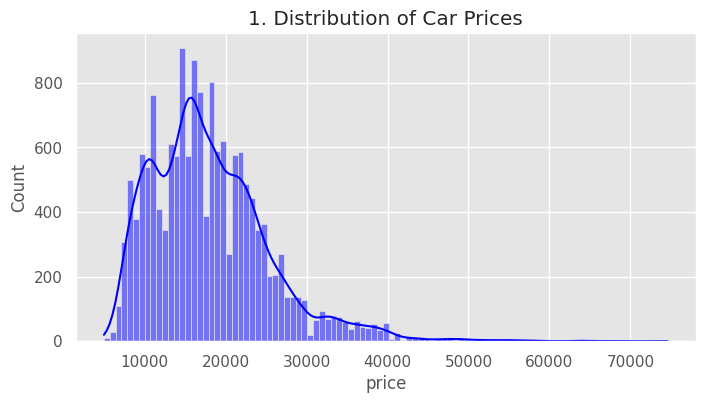

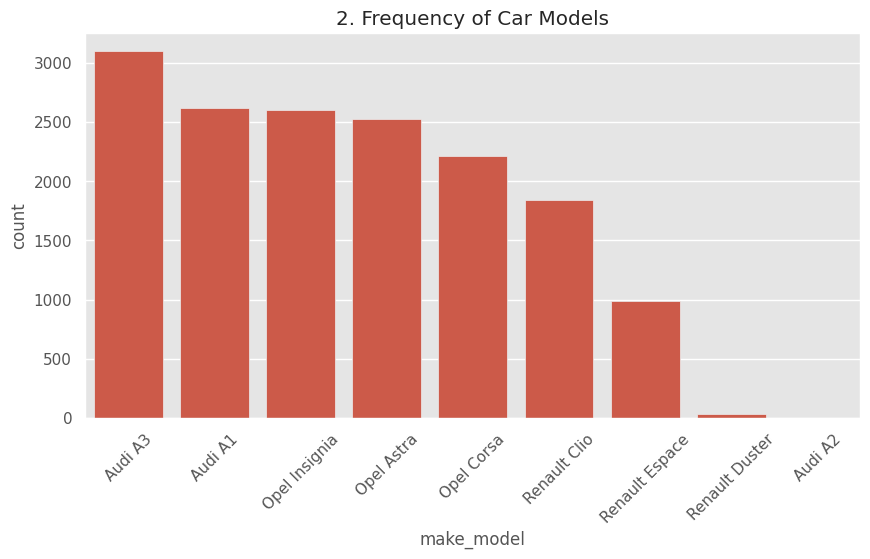

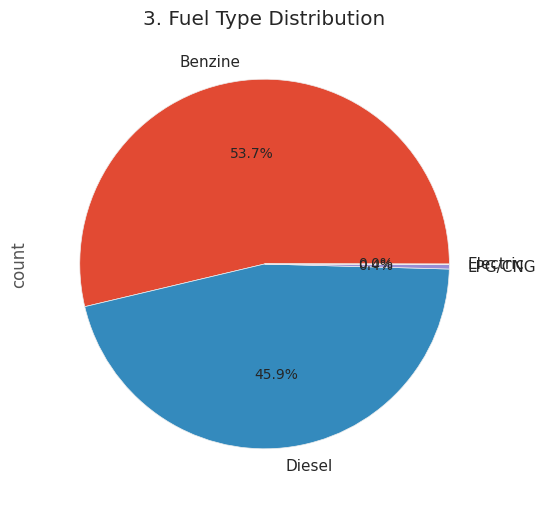

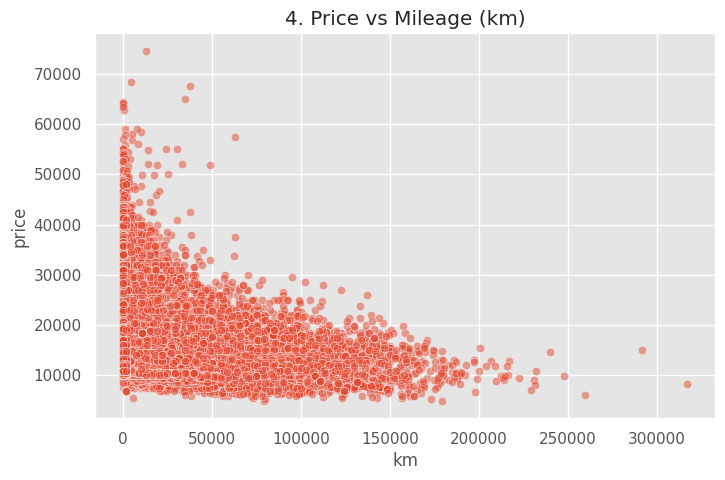

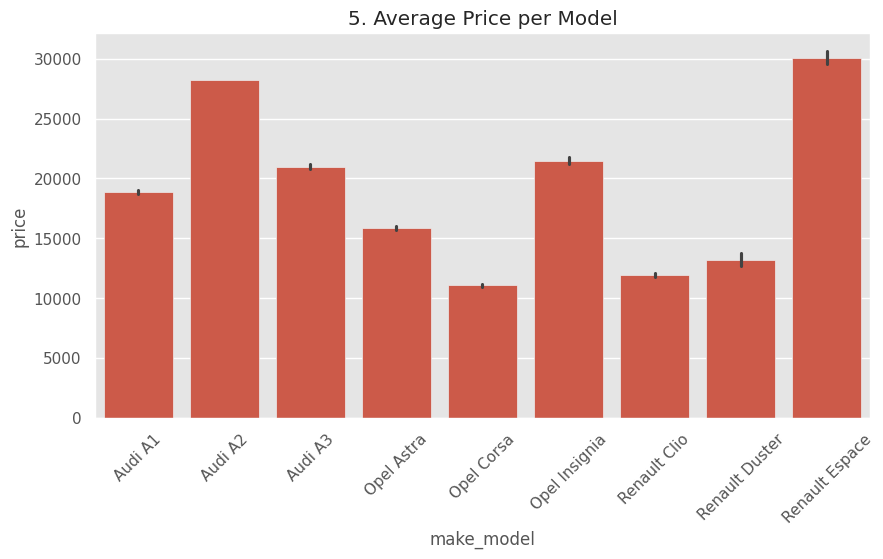

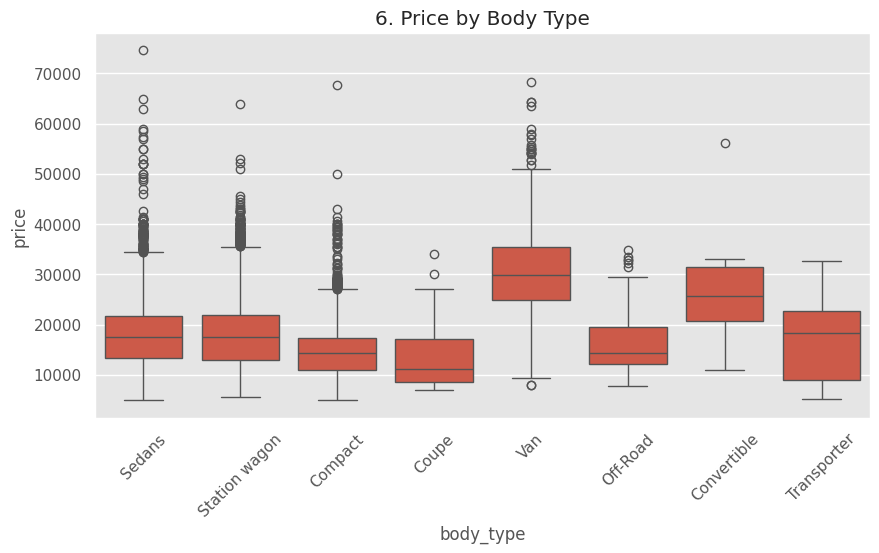

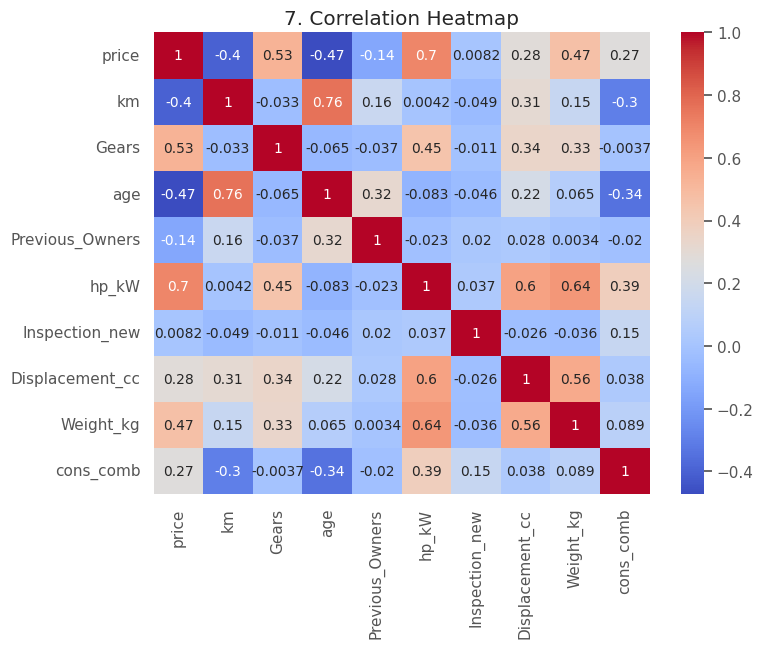

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use('ggplot')

# 1.(Histplot)
plt.figure(figsize=(8,4))
sns.histplot(df['price'], kde=True, color='blue')
plt.title('1. Distribution of Car Prices')
plt.show()

# 2.(Countplot)
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='make_model', order=df['make_model'].value_counts().index)
plt.xticks(rotation=45)
plt.title('2. Frequency of Car Models')
plt.show()

# 3. (Pie Chart)
plt.figure(figsize=(6,6))
df['Fuel'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('3. Fuel Type Distribution')
plt.show()

# 4.(Scatter Plot)
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='km', y='price', alpha=0.5)
plt.title('4. Price vs Mileage (km)')
plt.show()

# 5.(Bar Plot)
plt.figure(figsize=(10,5))
sns.barplot(data=df, x='make_model', y='price', estimator='mean')
plt.xticks(rotation=45)
plt.title('5. Average Price per Model')
plt.show()

# 6.(Box Plot)
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='body_type', y='price')
plt.xticks(rotation=45)
plt.title('6. Price by Body Type')
plt.show()

#7
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.title('7. Correlation Heatmap')
plt.show()

In [21]:

model_revenue = df.groupby('make_model')['price'].mean().sort_values(ascending=False)

print(model_revenue.head(10))

make_model
Renault Espace    30080.211907
Audi A2           28200.000000
Opel Insignia     21463.451886
Audi A3           20996.693252
Audi A1           18864.688982
Opel Astra        15840.834059
Renault Duster    13230.176471
Renault Clio      11940.320827
Opel Corsa        11061.841606
Name: price, dtype: float64


# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the following to the assignment 1 folder.
1. Dataset file
2. Dataset Description readme file
2. Jupyter Notebook
